## Step 0: Get your packages in order.

In [1]:
!pip install SimpleITK # This is a special library for visualising medical images.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.1 MB/s eta 0:00:00


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn as skl
import SimpleITK as sitk
import tensorflow as tf
from tensorflow import keras
import keras.backend as K
from keras import layers, Model

# 1. Download and Load the Training, Test and Validation Datasets

Data source: [BOston Neonatal Brain Injury Data](https://zenodo.org/records/10602767)


### *A Note on the Training Data* ###

The data consists of a special type of preprocessed MRI images, known as ADC maps.

*ADC: Apparent Diffusion Coefficient*
- It is a measure of the magnitude of diffusion (or movement) of water molecules across brain tissues.

- This molecular movement can be restricted due to structural damage in the brain, such as tumours or lesions.

- Areas where this happens tend to appear noticeably darker than surrounding areas on MRI images.

- These darker areas can help doctors to determine where these lesions or tumours could be located on the brain.

The ADC maps in the dataset have been categorised into three groups.

The first group contains raw, unedited, unprocessed images.

The second group comprises ADC maps that have undergone Z-score normalisation. This has been done to account for the fact that, under healthy conditions, different areas of the brain have different movement patterns of water molecules.

 So, Z-score normalisation is required to ensure that the movement of water molecules is compared across brain regions, according to each specific region's healthy baseline for molecular movement.

 The third group comprises binary masks of the images in which the brain lesions have been manually annotated by trained physicians.

 More information can be found on these pages:

 [Bao et al., 2023](https://www.biorxiv.org/content/10.1101/2023.06.30.546841v1.full)

 [Radiopaedia - Apparent Diffusion Coefficient](https://radiopaedia.org/articles/apparent-diffusion-coefficient-1)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip -q /content/drive/MyDrive/CSE602_Project_Data/train_data.zip
!unzip -q /content/drive/MyDrive/CSE602_Project_Data/val_data.zip
!tar -xvf /content/drive/MyDrive/CSE602_Project_Data/atlases.tar.gz
#!unzip -q /content/drive/MyDrive/CSE602_Project_Data/test_data.zip

atlases/
atlases/lesion_atlases/
atlases/lesion_atlases/readme.txt
atlases/lesion_atlases/lesion_atlas.nii.gz
atlases/normal_atlases/
atlases/normal_atlases/atlas_week0-1_masked.nii.gz
atlases/normal_atlases/readme_normal_atlases.txt
atlases/normal_atlases/brainmask_week0-1.nii.gz
atlases/normal_atlases/atlas_week0-1_stdev_masked.nii.gz
atlases/normal_atlases/brainmask_week0-1_excluding_ventricles.nii.gz


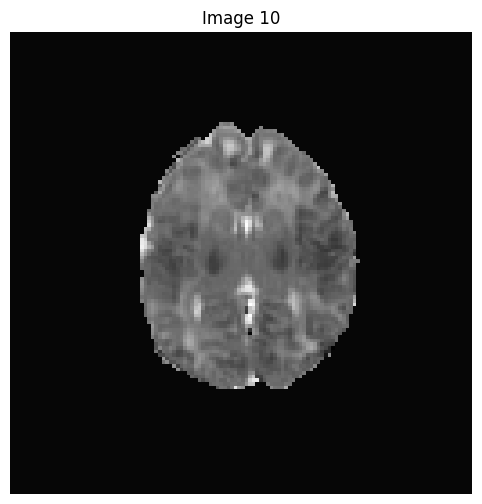

(128, 128, 23)


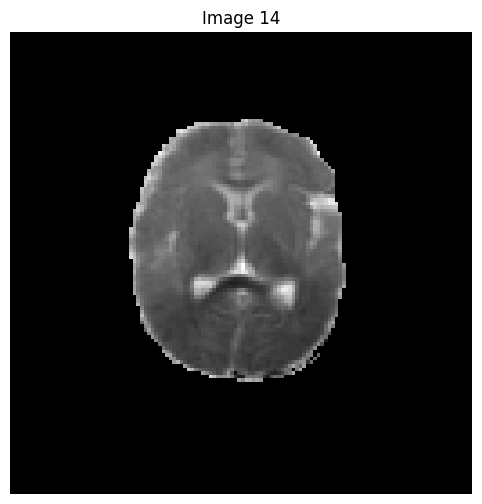

(128, 128, 23)


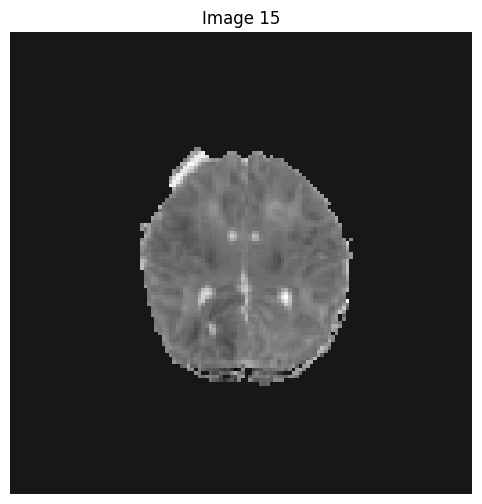

(128, 128, 23)


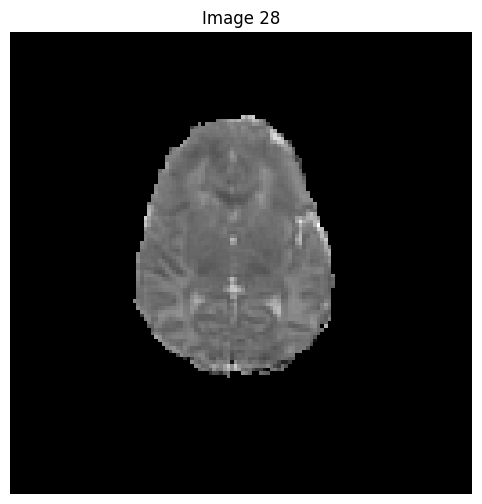

(128, 128, 23)


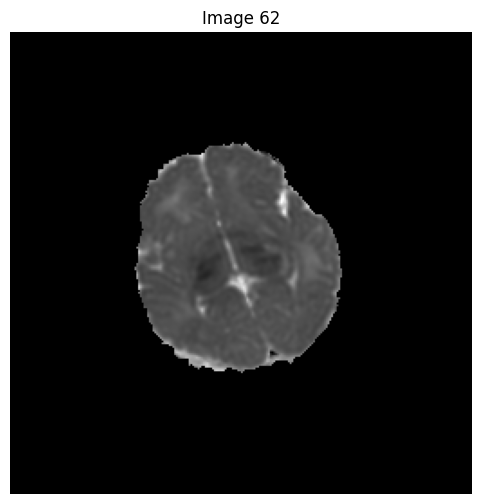

(256, 256, 19)


In [ ]:
#Some basic EDA; we read in and visualise the first five raw ADC maps to get a glimpse of the data we'll be dealing with.


train_dir = '/content/BONBID2023_Train'

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/1ADC_ss/MGHNICU_0{i}-VISIT_01-ADC_ss.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

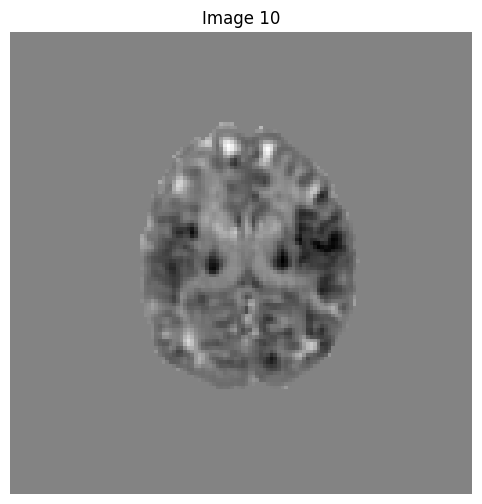

(128, 128, 23)


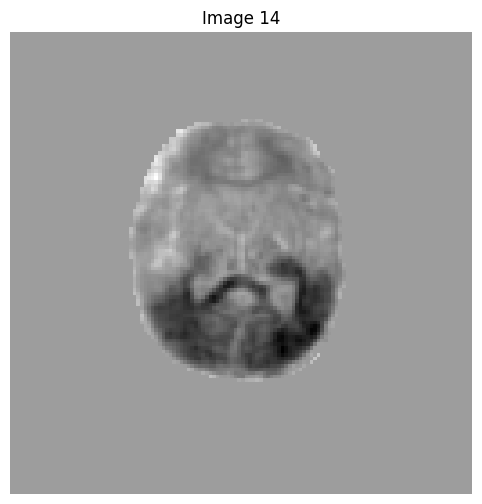

(128, 128, 23)


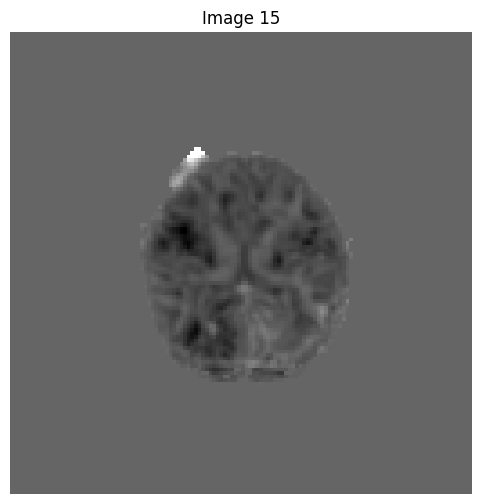

(128, 128, 23)


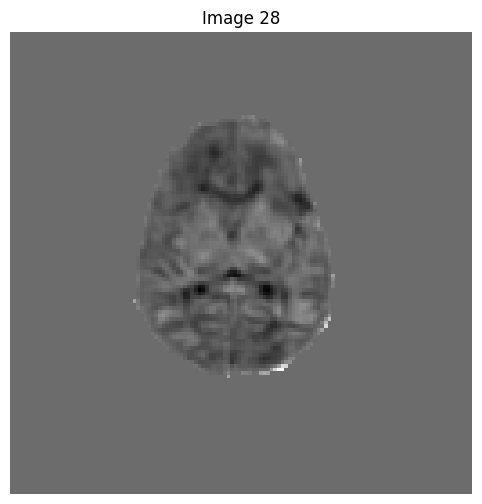

(128, 128, 23)


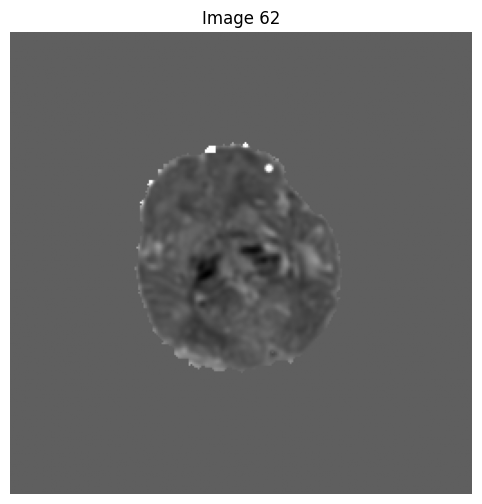

(256, 256, 19)


In [ ]:
# We do the same for the Z-score normalised ADC maps...

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/2Z_ADC/Zmap_MGHNICU_0{i}-VISIT_01-ADC_smooth2mm_clipped10.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

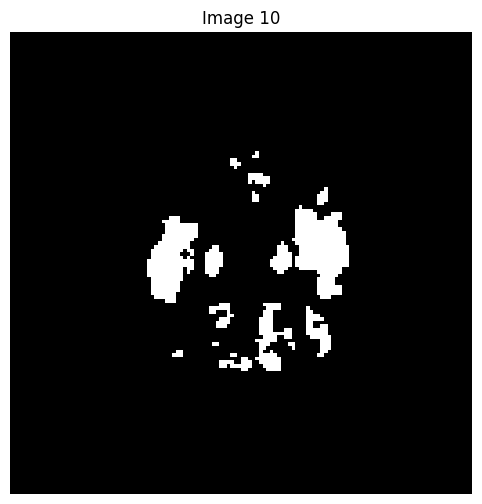

(128, 128, 23)


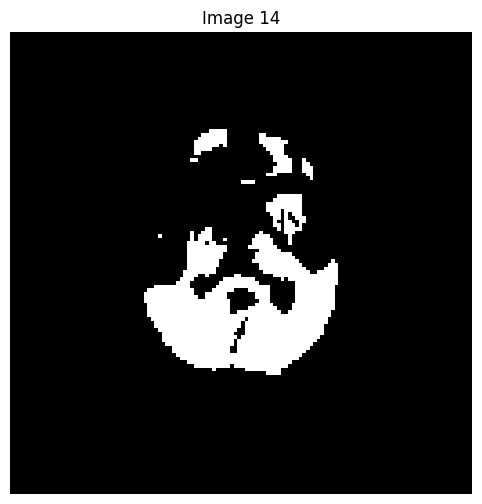

(128, 128, 23)


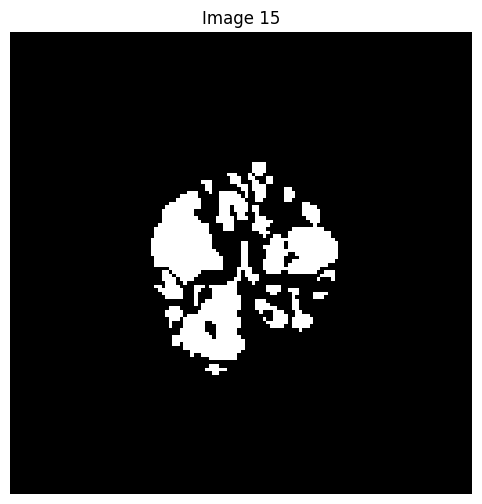

(128, 128, 23)


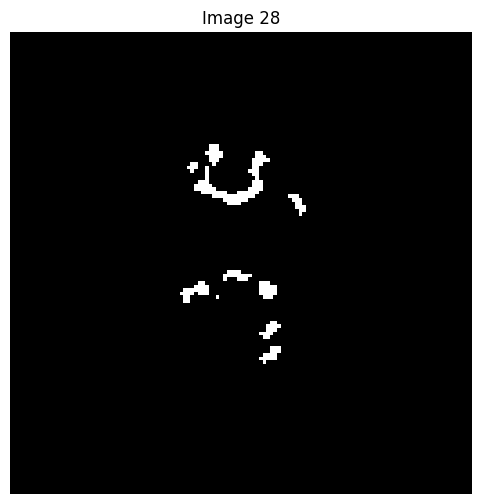

(128, 128, 23)


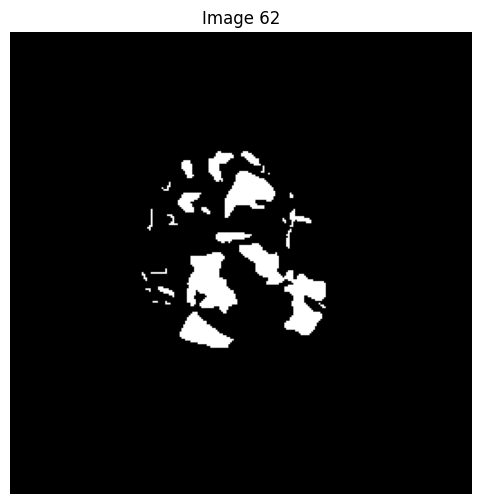

(256, 256, 19)


In [ ]:
# ...and for the binary image masks with brain lesions annotated by experts.
for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/3LABEL/MGHNICU_0{i}-VISIT_01_lesion.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

In [ ]:
file_path = '/content/atlases/lesion_atlases/readme.txt'

with open(file_path, 'r') as file:
  content = file.read()

In [ ]:
content

'The lesion atlas quantifies the frequency of lesions at each voxel in our cohort. It is in the same anatomic space as the normal_atlases/atlas_week0-1_masked.nii.gz image.\n'

In [ ]:
norm_path= '/content/atlases/normal_atlases/readme_normal_atlases.txt'

with open(norm_path, 'r') as file:
  norm_content = file.read()

In [ ]:
norm_content

'The normal atlases were reconstructed from 13 normative ADC maps scanned in 0-14 postnatal days. You can find more details in the following papers.\n\n- Ou, Y., Zöllei, L., Retzepi, K., Castro, V., Bates, S.V., Pieper, S., Andriole, K.P., Murphy, S.N., Gollub, R.L. and Grant, P.E., 2017. Using clinically acquired MRI to construct age-specific ADC atlases: Quantifying spatiotemporal ADC changes from birth to 6-year old. Human brain mapping, 38(6), pp.3052-3068.\n\n- Sotardi, S., Gollub, R.L., Bates, S.V., Weiss, R., Murphy, S.N., Grant, P.E. and Ou, Y., 2021. Voxelwise and regional brain apparent diffusion coefficient changes on MRI from birth to 6 years of age. Radiology, 298(2), pp.415-424.\n'

##2. Build and Train the Model

The chosen model architecture is the [2.5D Transformer Backbone U-Net Model](https://www.mdpi.com/2076-3425/15/8/778#:~:text=To%20evaluate%20the%20effectiveness%20of,diagnostic%20tools%20in%20clinical%20settings.).


This architecture has been chosen as it has achieved a Dice score of 0.8153 while segmented brain lesions in stroke patients.


The detailed rationale for this choice of architecture may be found in the explanatory project idea presentation which has been uploaded to this repository.


The following model architecture is a baseline architecture to implement this model. Parameters will be edited according to the model's performance on initial runs.

In [4]:
def transformer_block(x, num_heads = 4, key_dim = 64, mlp_dim = 256, dropout = 0.1):
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    mlp_out = layers.Dense(mlp_dim, activation='gelu')(x)
    mlp_out = layers.Dense(x.shape[-1])(mlp_out)
    mlp_out = layers.Dropout(dropout)(mlp_out)
    x = layers.Add()([x, mlp_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

In [5]:
def build_2_5d_transunet(input_shape=(128, 128, 23), num_classes = 1):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(128, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(128, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    shape = p2.shape
    patch_dim = shape[-1]
    flattened = layers.Reshape((shape[1] * shape[2], patch_dim))(p2)

    t1 = transformer_block(flattened)
    t2 = transformer_block(t1)

    t_feat = layers.Reshape((shape[1], shape[2], patch_dim))(t2)
    t_feat = layers.Conv2D(128, 3, padding='same', activation='relu')(t_feat)

    u1 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(t_feat)
    u1 = layers.concatenate([u1, c1])
    d1 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    d1 = layers.Conv2D(64, 3, activation='relu', padding='same')(d1)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(d1)

    return Model(inputs, outputs)

In [8]:
model = build_2_5d_transunet()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 23)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │     13,312 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_17[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1024, 128) │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 128) │    131,968 │ reshape_4[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 1024, 128) │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 1024, 128) │          0 │ reshape_4[0][0],  │
│                     │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 128) │        256 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1024, 256) │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1024, 128) │     32,896 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 1024, 128) │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 1024, 128) │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 128) │        256 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 128) │    131,968 │ layer_normalizat

 Total params: 1,467,969 (5.60 MB)

 Trainable params: 1,467,969 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# We need to define a helper function to calculate the Dice coefficient as Keras does not provide this as a built-in metric.
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice


In [11]:
model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001), loss = keras.losses.Dice(), metrics = [dice_coef])